# Sphere Collision Analysis

Diagnostics for the four elastic-collision C++ programs in this project (`part1_equal_mass.cpp` through `part4_pool_table.cpp`). Each section reads the CSV output of the corresponding program from `data/` and plots it.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

# Small fixed categorical palette, used in a consistent order across all plots.
BLUE = "#4C72B0"
ORANGE = "#DD8452"
GREEN = "#55A868"
RED = "#C44E52"

plt.rcParams["figure.figsize"] = (8, 6)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False

## Part 1: Equal-Mass Collision

`H(v2f)` is the residual of the x-momentum equation; its root is the physical final speed of sphere 2. The bracket bug (bisecting on `[0, v1i]`, which strays into a domain where `asin()` is undefined for any offset `d > 0`) is fixed in `part1_equal_mass.cpp` — no clamp is used anywhere in the ported code.

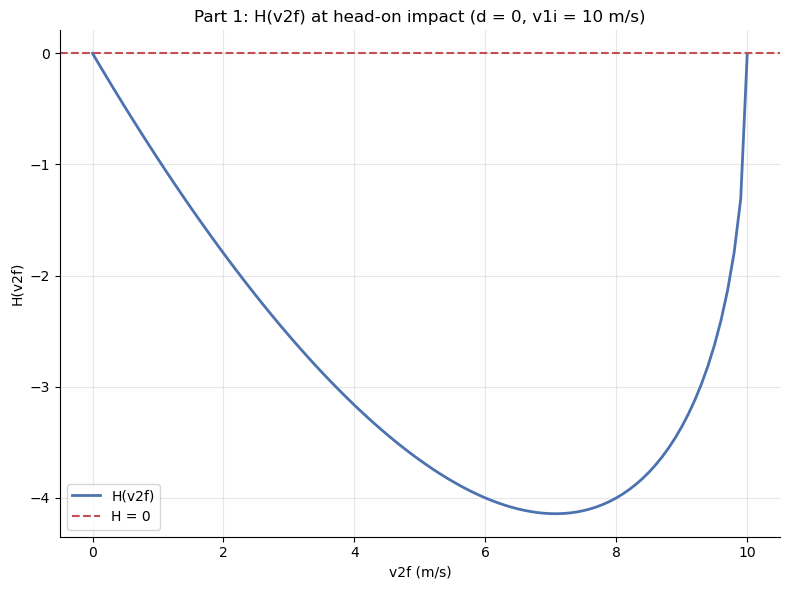

In [2]:
df = pd.read_csv("data/H_curve.csv")

plt.figure()
plt.plot(df["v2f"], df["H"], color=BLUE, linewidth=2, label="H(v2f)")
plt.axhline(0, color=RED, linestyle="dashed", linewidth=1.5, label="H = 0")
plt.xlabel("v2f (m/s)")
plt.ylabel("H(v2f)")
plt.title("Part 1: H(v2f) at head-on impact (d = 0, v1i = 10 m/s)")
plt.legend()
plt.tight_layout()
plt.savefig("data/H_curve_part1.png", dpi=150)
plt.show()

The root sits exactly at `v2f = v1i` for a head-on impact (all of sphere 1's speed is transferred to sphere 2), matching the closed-form check `v2f = v1i * cos(theta)` at `theta = 0`.

### Final speed vs. impact offset

`v2f`, as a percentage of `v1i`, plotted against the impact offset `d` (the perpendicular distance between the centers' approach line). This curve comes straight out of the fixed bisection — no clamp is applied, and it turns out to be genuinely monotonic on its own.

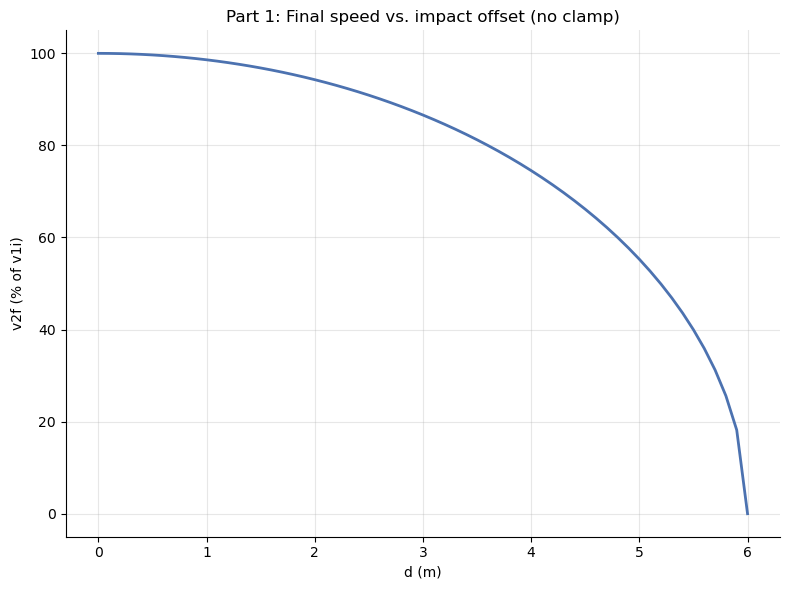

In [3]:
df = pd.read_csv("data/v2f_vs_offset.csv")

plt.figure()
plt.plot(df["d"], df["v2f_percent"], color=BLUE, linewidth=2)
plt.xlabel("d (m)")
plt.ylabel("v2f (% of v1i)")
plt.title("Part 1: Final speed vs. impact offset (no clamp)")
plt.tight_layout()
plt.savefig("data/v2f_vs_offset.png", dpi=150)
plt.show()

## Part 2: Unequal-Mass Collision

Same `H(v2f)` residual, now carrying the mass ratio `m2/m1`. The original source computed the `m2 > m1` root but never printed it; `part2_unequal_mass.cpp` reports both cases symmetrically.

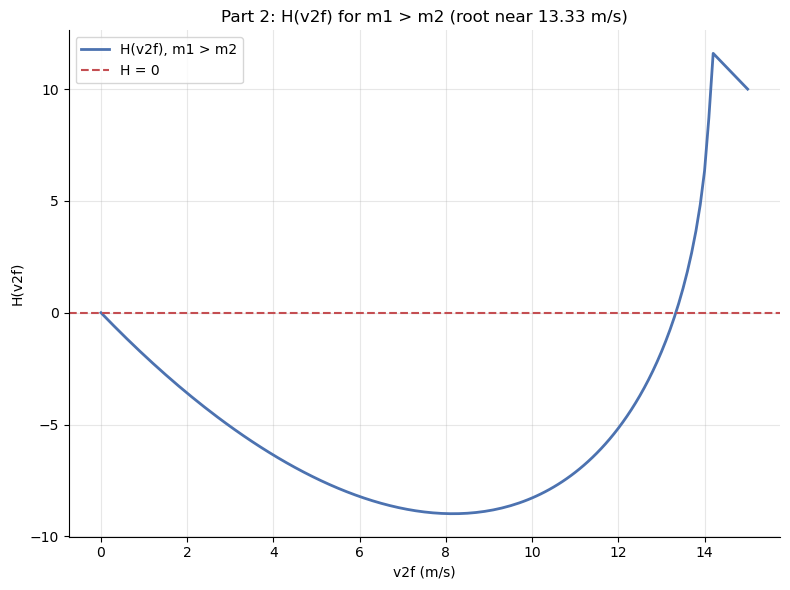

In [4]:
df = pd.read_csv("data/m1_greater_H.csv").sort_values(by="v2f")

plt.figure()
plt.plot(df["v2f"], df["H"], color=BLUE, linewidth=2, label="H(v2f), m1 > m2")
plt.axhline(0, color=RED, linestyle="dashed", linewidth=1.5, label="H = 0")
plt.xlabel("v2f (m/s)")
plt.ylabel("H(v2f)")
plt.title("Part 2: H(v2f) for m1 > m2 (root near 13.33 m/s)")
plt.legend()
plt.tight_layout()
plt.show()

### m2 > m1

Note: `H(v2f)` is negative across the *entire* valid domain for this case (never reaches 0). At exact head-on incidence, `theta = phi = 0` is forced, which pins `cos(phi) = 1` — the model can then only represent sphere 1 continuing forward, not bouncing backward. Since m2 > m1 physically means sphere 1 *should* bounce backward, no interior root exists; this is a structural property of the theta=0 model, not a numerical bug (see comments in `part2_unequal_mass.cpp`).

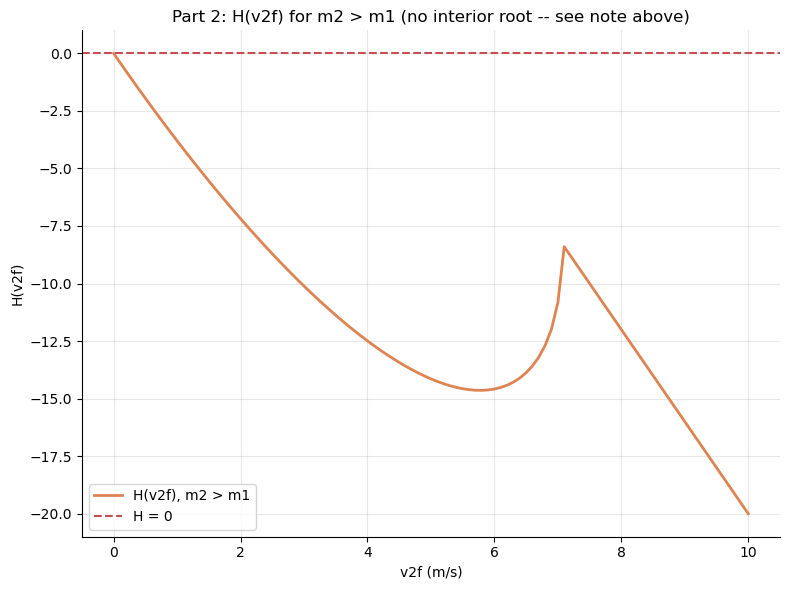

In [5]:
df = pd.read_csv("data/m2_greater_H.csv").sort_values(by="v2f")

plt.figure()
plt.plot(df["v2f"], df["H"], color=ORANGE, linewidth=2, label="H(v2f), m2 > m1")
plt.axhline(0, color=RED, linestyle="dashed", linewidth=1.5, label="H = 0")
plt.xlabel("v2f (m/s)")
plt.ylabel("H(v2f)")
plt.title("Part 2: H(v2f) for m2 > m1 (no interior root -- see note above)")
plt.legend()
plt.tight_layout()
plt.show()

## Part 3: Oblique Incidence Angle alpha

The original program only ever evaluated one hardcoded `alpha = 30 deg`. `part3_oblique_angle.cpp` derives the physically valid range from the grazing-impact geometry (Figure 5 in the PDF: an isosceles triangle gives `alpha_max = asin((r1+r2)/D)`, which works out to about 36.87 deg here — notably wider than the original 30 deg sample) and sweeps 80 steps across `[0, alpha_max)` for both mass-ratio cases.

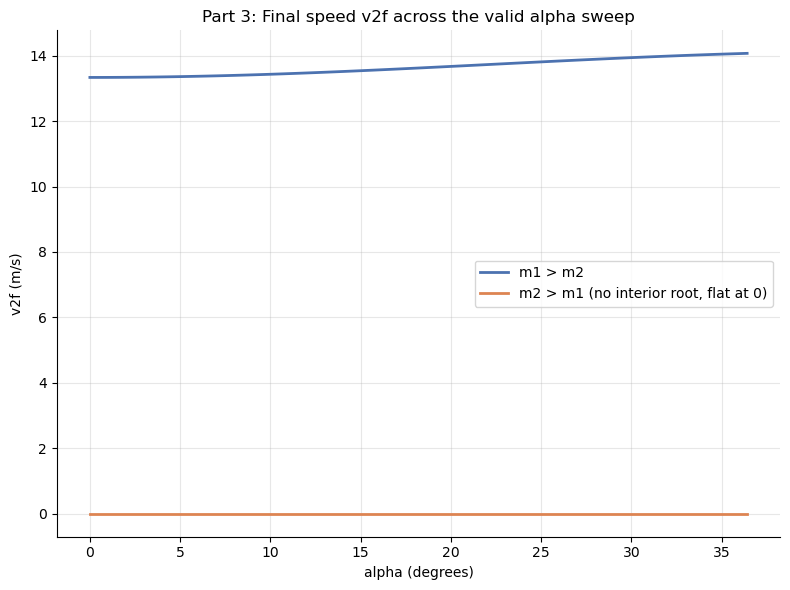

In [6]:
df_m1 = pd.read_csv("data/m1_greater_alpha.csv")
df_m2 = pd.read_csv("data/m2_greater_alpha.csv")

plt.figure()
plt.plot(df_m1["alpha_deg"], df_m1["v2f"], color=BLUE, linewidth=2, label="m1 > m2")
plt.plot(df_m2["alpha_deg"], df_m2["v2f"], color=ORANGE, linewidth=2, label="m2 > m1 (no interior root, flat at 0)")
plt.xlabel("alpha (degrees)")
plt.ylabel("v2f (m/s)")
plt.title("Part 3: Final speed v2f across the valid alpha sweep")
plt.legend()
plt.tight_layout()
plt.savefig("data/alpha_sweep.png", dpi=150)
plt.show()

For `m1 > m2`, `v2f` *increases* slightly with alpha (about 13.33 m/s at alpha=0 up to 14.07 m/s near alpha_max) rather than decreasing as one might first guess. The reason: alpha only weakens the momentum constraint along the line of centers, while sphere 1's total kinetic energy budget (which sets the fixed ceiling `v2fMax = v1i/sqrt(m2/m1)`) stays the same -- a weaker momentum constraint against a fixed energy budget pushes the root closer to that ceiling, not further from it. No NaNs occur anywhere in the sweep for either mass case.

## Part 4: Pool Table (Frictionless vs. With Friction)

White ball hits purple ball (swept along y from 15 cm to 120 cm), which hits red ball. The plot shows the minimum white-ball initial speed needed for the red ball to reach its target corner at >= 1 cm/s, as a function of the purple ball's y position. The original program only implemented the friction case; `part4_pool_table.cpp` adds a `simulate(bool withFriction)` frictionless variant sharing the same code path.

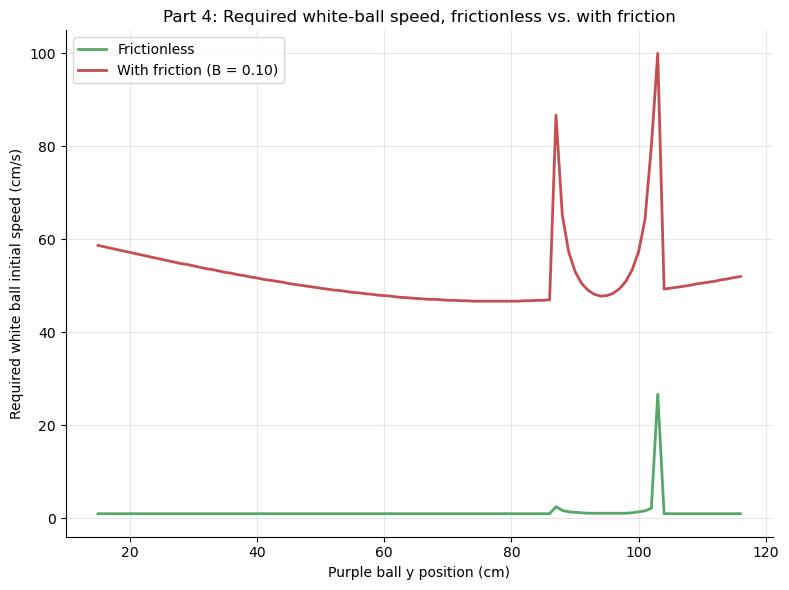

In [7]:
df_nofric = pd.read_csv("data/results_frictionless.csv")
df_fric = pd.read_csv("data/results_with_friction.csv")

plt.figure()
plt.plot(df_nofric["purple_y_cm"], df_nofric["white_vi_cm_s"], color=GREEN, linewidth=2, label="Frictionless")
plt.plot(df_fric["purple_y_cm"], df_fric["white_vi_cm_s"], color=RED, linewidth=2, label="With friction (B = 0.10)")
plt.xlabel("Purple ball y position (cm)")
plt.ylabel("Required white ball initial speed (cm/s)")
plt.title("Part 4: Required white-ball speed, frictionless vs. with friction")
plt.legend()
plt.tight_layout()
plt.savefig("data/friction_comparison.png", dpi=150)
plt.show()

As a validation check: the frictionless curve sits consistently below and flatter than the with-friction curve (roughly 1-27 cm/s required vs. 47-100 cm/s), which is the expected sanity result -- with no drag, momentum and kinetic energy pass through the two intermediate collisions with far less loss, so a much smaller white-ball speed suffices to give the red ball its required 1 cm/s exit speed.